Dataset Shape: (100, 3)
First 5 Rows:
        x1        x2  label
0  0.78051 -0.063669      1
1  0.28774  0.291390      1
2  0.40714  0.178780      1
3  0.29230  0.421700      1
4  0.50922  0.352560      1

No missing values found.

Final Weights: w1 =  -4.711567096949909  w2 =  -8.081529194119398  b =  4.84114316166169


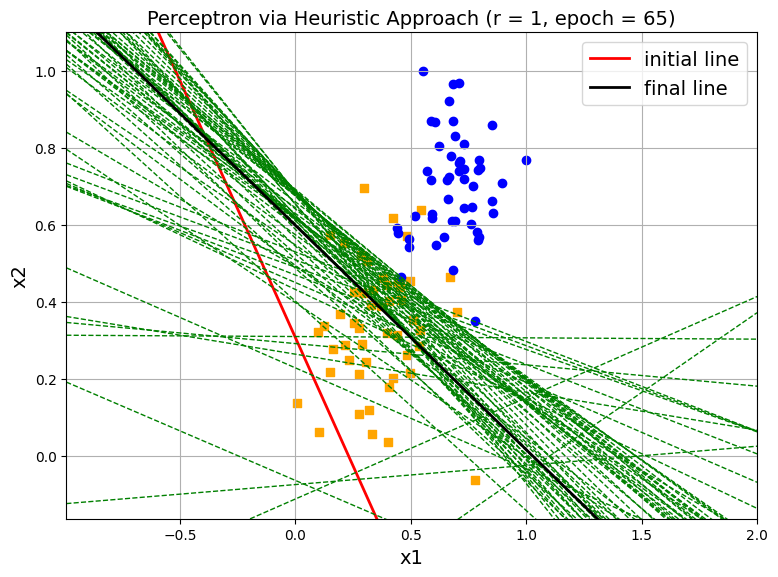

In [1]:
# Author: Joseph Lorenzo Bautista
# Class: CSCI 580 - Artificial Intelligence
# Assignment: Assignment #6 - Perceptron -> Neuron - Heuristic Approach

import sys
import random
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

assert sys.version_info >= (3, 7)

# Formatting and saving the figures
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Image path and savings
IMAGES_PATH = Path() / "PerceptronPlots" 
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Reads/gets the .csv file
data_path = "data-1.csv"
df = pd.read_csv(data_path, header=None, names=["x1", "x2", "label"])

print("Dataset Shape:", df.shape)
print("First 5 Rows:")
print(df.head())

# Checks for any missing values
if df.isna().any().any():
    print("\nWarning: Data set contains missing values:")
    print(df.isna().sum())
else:
    print("\nNo missing values found.")

# Pulling the columns out (x1 = first column, x2 = second column, label = third)
x1_list = df.iloc[:, 0].tolist()
x2_list = df.iloc[:, 1].tolist()
labels  = df.iloc[:, 2].astype(int).tolist()
n_points = len(x1_list)

# Step #1: starting with random weights and bias
random.seed(0)
w1  = random.uniform(-1, 1)
w2  = random.uniform(-1, 1)
b   = random.uniform(-1, 1)

r = 1
num_epochs = 65

# Helper that classifies one point
def classify(x1, x2, w1, w2, b):
    if w1 * x1 + w2 * x2 + b >= 0:
        return 1
    else:
        return 0
    
# Helper that gets the line endpoints
x_min = min(x1_list) - 1
x_max = max(x1_list) + 1

def line_points(w1, w2, b):
    # Solves and calculates
    xs = [x_min, x_max]
    if w2 == 0:
        w2_safe = 0.0001
    else:
        w2_safe = w2
    ys = [-(w1 * xs[0] + b) / w2_safe, -(w1 * xs[1] + b) / w2_safe]

    return xs, ys

# Setting up the plot/graph
plt.figure(figsize=(8,6))

# Plotting the data points
for i in range(n_points):
    if labels[i] == 0:
        plt.scatter(x1_list[i], x2_list[i], color="blue", marker="o")
    else:
        plt.scatter(x1_list[i], x2_list[i], color="orange", marker="s")

# Plotting the initial line
xs, ys = line_points(w1, w2, b)
plt.plot(xs, ys, color="red", linewidth=2, label="initial line")

# Step #2 and Step #3: training the perceptron
for epoch in range(num_epochs):
    for i in range(n_points):
        x1 = x1_list[i]
        x2 = x2_list[i]
        y = labels[i]

        guess = classify(x1, x2, w1, w2, b)

        if guess != y:
            if guess == 0:
                
                b = b + r
                w1 = w1 + r * x1
                w2 = w2 + r * x2
            else:
                b = b - r
                w1 = w1 - r * x1
                w2 = w2 - r * x2

    if epoch < num_epochs - 1:
        xs, ys = line_points(w1, w2, b)
        plt.plot(xs, ys, color="green", linestyle="--", linewidth=1)

# Plotting the black line in the chart/graph
xs, ys = line_points(w1, w2, b)
plt.plot(xs, ys, color="black", linewidth=2, label="final line")

print("\nFinal Weights: w1 = ", w1, " w2 = ", w2, " b = ", b)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Perceptron via Heuristic Approach (r = {r}, epoch = {num_epochs})")
plt.legend()
plt.grid(True)
plt.xlim(x_min, x_max)
plt.ylim(min(x2_list) - 0.1, max(x2_list) + 0.1)

save_fig(f"perceptron_heuristic_r{r}")
plt.show()

Dataset Shape: (100, 3)
First 5 Rows:
        x1        x2  label
0  0.78051 -0.063669      1
1  0.28774  0.291390      1
2  0.40714  0.178780      1
3  0.29230  0.421700      1
4  0.50922  0.352560      1

No missing values found.

Final Weights: w1 =  -16.455872670713813  w2 =  -20.394294553344334  b =  17.93152692258983
Final Log Loss:  0.17513370515531024


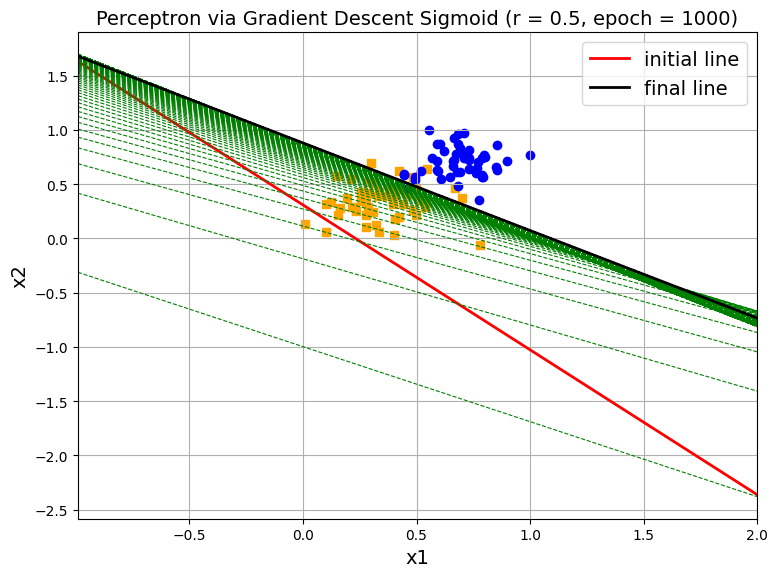

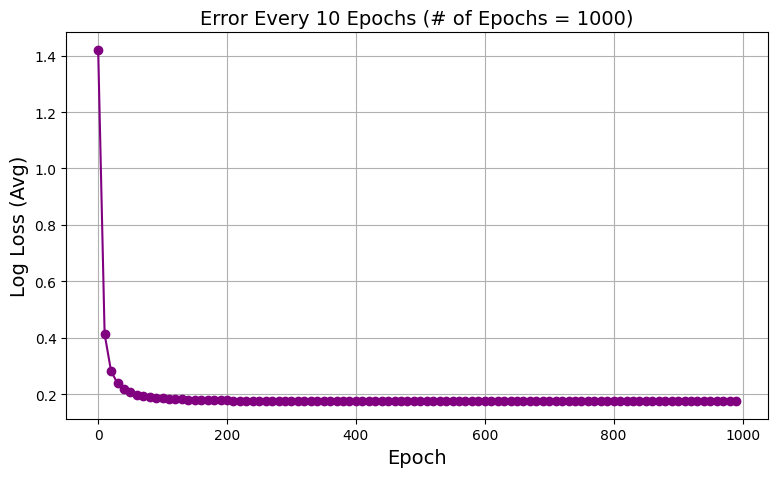

In [2]:
# Author: Joseph Lorenzo Bautista
# Class: CSCI 580 - Artificial Intelligence
# Assignment: Assignment #6 - Perceptron -> Neuron - Gradient Descent Approach

import sys
import math
import random
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

assert sys.version_info >= (3, 7)

# Formatting and saving the figures
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Image path and savings
IMAGES_PATH = Path() / "PerceptronPlots" 
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Reads/gets the .csv file
data_path = "data-1.csv"
df = pd.read_csv(data_path, header=None, names=["x1", "x2", "label"])

print("Dataset Shape:", df.shape)
print("First 5 Rows:")
print(df.head())

# Checks for any missing values
if df.isna().any().any():
    print("\nWarning: Data set contains missing values:")
    print(df.isna().sum())
else:
    print("\nNo missing values found.")

# Pulling the columns out (x1 = first column, x2 = second column, label = third)
x1_list = df.iloc[:, 0].tolist()
x2_list = df.iloc[:, 1].tolist()
labels  = df.iloc[:, 2].astype(int).tolist()
n_points = len(x1_list)

# Sigmoid Function
def sigmoid(z):
    if z < -500:
        z = -500
    if z > 500:
        z = 500
    return 1.0 / (1.0 + math.exp(-z))

# Step #1: starting with random weights and bias
random.seed(0)
w1  = random.uniform(-1, 1)
w2  = random.uniform(-1, 1)
b   = random.uniform(-1, 1)

r = 0.5
num_epochs = 1000

# Helper that gets the line endpoints
x_min = min(x1_list) - 1
x_max = max(x1_list) + 1

def line_points(w1, w2, b):
    # Solves and calculates
    xs = [x_min, x_max]
    if w2 == 0:
        w2_safe = 0.0001
    else:
        w2_safe = w2
    ys = [-(w1 * xs[0] + b) / w2_safe, -(w1 * xs[1] + b) / w2_safe]

    return xs, ys

# Setting up the plot/graph
plt.figure(figsize=(8, 6))

# Plotting the data points
for i in range(n_points):
    if labels[i] == 0:
        plt.scatter(x1_list[i], x2_list[i], color="blue", marker="o")
    else:
        plt.scatter(x1_list[i], x2_list[i], color="orange", marker="s")

# Plotting the initial line
xs, ys = line_points(w1, w2, b)
plt.plot(xs, ys, color="red", linewidth=2, label="initial line")

# Step #2 & Step #3: training using Gradient Descent
errors_per_epoch = []

for epoch in range(num_epochs):

    for i in range(n_points):
        x1  = x1_list[i]
        x2  = x2_list[i]
        y   = labels[i]

        z = w1 * x1 + w2 * x2 + b  
        y_hat = sigmoid(z)

        err = y - y_hat

        b   = b + r * err
        w1  = w1 + r * err * x1
        w2  = w2 + r * err * x2

    # Calculate the total log loss across all of the points
    total_loss = 0.0
    for i in range(n_points):
        z = w1 * x1_list[i] + w2 * x2_list[i] + b
        y_hat = sigmoid(z)

        if y_hat < 1e-12:
            y_hat = 1e-12
        if y_hat > 1 - 1e-12:
            y_hat = 1 - 1e-12
        y = labels[i]
        total_loss = total_loss - (y * math.log(y_hat) + (1 - y) * math.log(1 - y_hat))
    avg_loss = total_loss / n_points
    errors_per_epoch.append(avg_loss)

    # Making each intermediate line dashed green
    if epoch < num_epochs - 1:
        xs, ys = line_points(w1, w2, b)
        plt.plot(xs, ys, color="green", linestyle="--", linewidth=0.8)

# Plotting the black line in the chart/graph
xs, ys = line_points(w1, w2, b)
plt.plot(xs, ys, color="black", linewidth=2, label="final line")

print("\nFinal Weights: w1 = ", w1, " w2 = ", w2, " b = ", b)
print("Final Log Loss: ", errors_per_epoch[-1])

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Perceptron via Gradient Descent Sigmoid (r = {r}, epoch = {num_epochs})")
plt.legend()
plt.grid(True)
plt.xlim(x_min, x_max)

save_fig(f"perceptron_gd_r{r}")
plt.show()

# Error and Log Loss graphing
plt.figure(figsize=(8, 5))

epoch_marks = []
error_marks = []

for e in range(num_epochs):
    if e % 10 == 0:
        epoch_marks.append(e)
        error_marks.append(errors_per_epoch[e])

plt.plot(epoch_marks, error_marks, color="purple", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Log Loss (Avg)")
plt.title(f"Error Every 10 Epochs (# of Epochs = {num_epochs})")
plt.grid(True)

save_fig(f"perceptron_gd_error_{num_epochs}")
plt.show()
